# Reading cached visual query extents

This exploratory study distinguishes image pooling, a common
contextualized token, and the visible pixels at that token.
Initial galleries withheld metadata labels; earlier project
examples were known. It is not an independent blinded benchmark.

Sources: `src/lattmc/vision/semantic_*_codexgen.py`.
Frozen inventory: 372 queries; visual follow-ups: 32 queries.
Sixteen threshold checks are reported separately.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display

root = Path.cwd()
folder = root / "vision_tokens/overcomplete/results"
folder = folder / "semantic_reading"
models = ["topk_k32_s0", "prisma_transcoder",
          "pretrained_ra"]
inventory = pd.read_json(
    folder / "inventory_codexgen.json")
assert len(inventory) == 404
inventory.groupby(["model", "family"])[
    ["pooled", "common", "patches"]].agg(["count", "median"])

pooled        common        patches         
                                   count median  count median   count   median
model             family                                                      
pretrained_ra     coactive            20    0.0     20    0.0      20      0.0
                  existing            16    6.0     16    5.5      16     72.0
                  lowcorr             20    0.0     20    0.0      20      0.0
                  random              20    0.0     20    0.0      20      0.0
                  single              24    6.0     24    6.0      24    102.5
                  source              24  273.5     24  273.5      24  16370.5
                  visual_followup      6    0.5      6    0.0       6      0.0
prisma_transcoder coactive            20  163.0     20    4.0      20      4.5
                  existing            16  250.5     16  154.5      16    200.5
                  lowcorr             20   46.5     20    0.0      20      0.0
                  random              20   49.5     20    0.0      20      0.0
                  single              24  231.0     24  231.0      24    467.5
                  source              24    3.0     24    0.0      24      0.0
                  visual_followup      8  200.0      8    0.0       8      0.0
topk_k32_s0       coactive            20  147.5     20    3.5      20      4.0
                  existing            16  264.0     16  260.5      16   1435.5
                  lowcorr             20    0.0     20    0.0      20      0.0
                  random              20    2.0     20    0.0      20      0.0
                  single              24  120.5     24  120.5      24    786.5
                  source              24   33.0     24   33.0      24    315.5
                  visual_followup     18   40.0     18    0.0      18      0.0

## Exact operations and component comparisons

For nonnegative codes, `G(q)` tests every threshold
against the image maxima. `H(q)` requires one token
to satisfy all thresholds. A vector join intersects
pooled extents; a meet can exceed their union. Closing
a query on this finite context preserves its extent.

In [2]:
records = []
for model in models:
    path = folder / f"{model}_followup_codexgen.json"
    for row in json.loads(path.read_text())["results"]:
        records.append({"model": model, **row})
columns = ["model", "name", "features", "query",
           "component_pooled", "pooled", "common",
           "patch_count"]
pd.DataFrame(records)[columns]

,model,name,features,query,component_pooled,pooled,common,patch_count
0,topk_k32_s0,face2_q50,"[329, 507]","[3.25716495513916, 2.6789283752441406]","[369, 352]",350,348,4363
1,topk_k32_s0,face2_q80,"[329, 507]","[5.626354217529297, 6.617412090301514]","[316, 246]",238,231,992
2,topk_k32_s0,face3_q50,"[329, 507, 1271]","[3.25716495513916, 2.6789283752441406, 1.84011...","[369, 352, 410]",348,207,862
3,topk_k32_s0,face3_q80,"[329, 507, 1271]","[5.626354217529297, 6.617412090301514, 3.76482...","[316, 246, 332]",233,3,3
4,topk_k32_s0,face4_q50,"[329, 507, 1271, 1430]","[3.25716495513916, 2.6789283752441406, 1.84011...","[369, 352, 410, 364]",343,166,402
5,topk_k32_s0,face4_q80,"[329, 507, 1271, 1430]","[5.626354217529297, 6.617412090301514, 3.76482...","[316, 246, 332, 322]",229,0,0
6,topk_k32_s0,face6_q50,"[329, 507, 1271, 1430, 871, 468]","[3.25716495513916, 2.6789283752441406, 1.84011...","[369, 352, 410, 364, 334, 352]",306,5,6
7,topk_k32_s0,face6_q80,"[329, 507, 1271, 1430, 871, 468]","[5.626354217529297, 6.617412090301514, 3.76482...","[316, 246, 332, 322, 228, 286]",175,0,0
8,topk_k32_s0,structure2_q50,"[282, 798]","[2.0798404216766357, 2.488508701324463]","[95, 106]",29,7,11
9,topk_k32_s0,structure2_q80,"[282, 798]","[4.936252117156982, 4.211187362670898]","[24, 50]",7,0,0


## Independent saved-mask checks

All 404 outcomes, including failures, are checked.
The source modules additionally recompute extents and
closures from the original sparse activation caches.

In [3]:
checked = 0
for model in models:
    for suffix in ["", "_followup"]:
        stem = f"{model}{suffix}"
        path = folder / f"{stem}_codexgen.json"
        rows = json.loads(path.read_text())["results"]
        path = folder / f"{stem}_masks_codexgen.npz"
        with np.load(path) as masks:
            for row in rows:
                name = row["name"]
                patch = masks[f"{name}__patch"]
                common = masks[f"{name}__common"]
                pooled = masks[f"{name}__pooled"]
                assert patch.sum() == row["patch_count"]
                assert common.sum() == row["common"]
                assert pooled.sum() == row["pooled"]
                assert np.array_equal(patch.any(1), common)
                assert np.all(common <= pooled)
                checked += 1
assert checked == 404
print(f"Verified {checked} query outcomes.")

Verified 404 query outcomes.


## Visual readings and numerical witnesses

Red cells are common witnesses. Numbered blue cells
are separate coordinate maxima. The whole image is
needed: a tiger response lies above the face, while
a texture query responds to vegetation beside a vehicle.
Margins near one and alternative explanations matter.

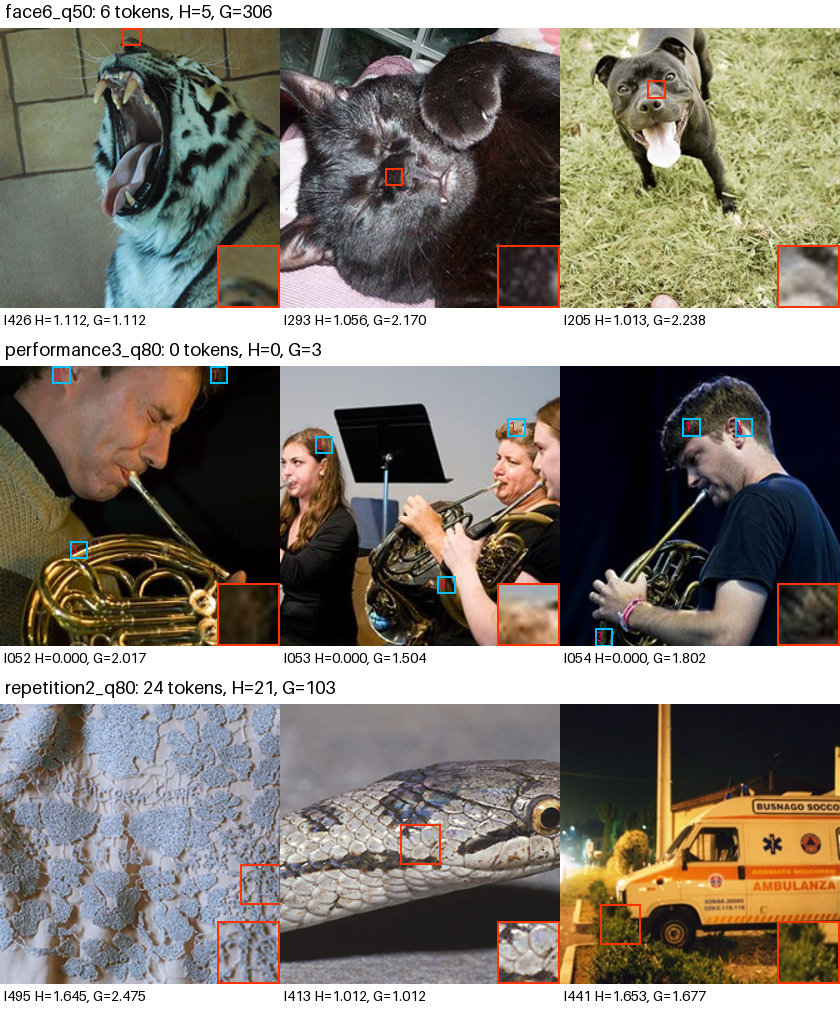

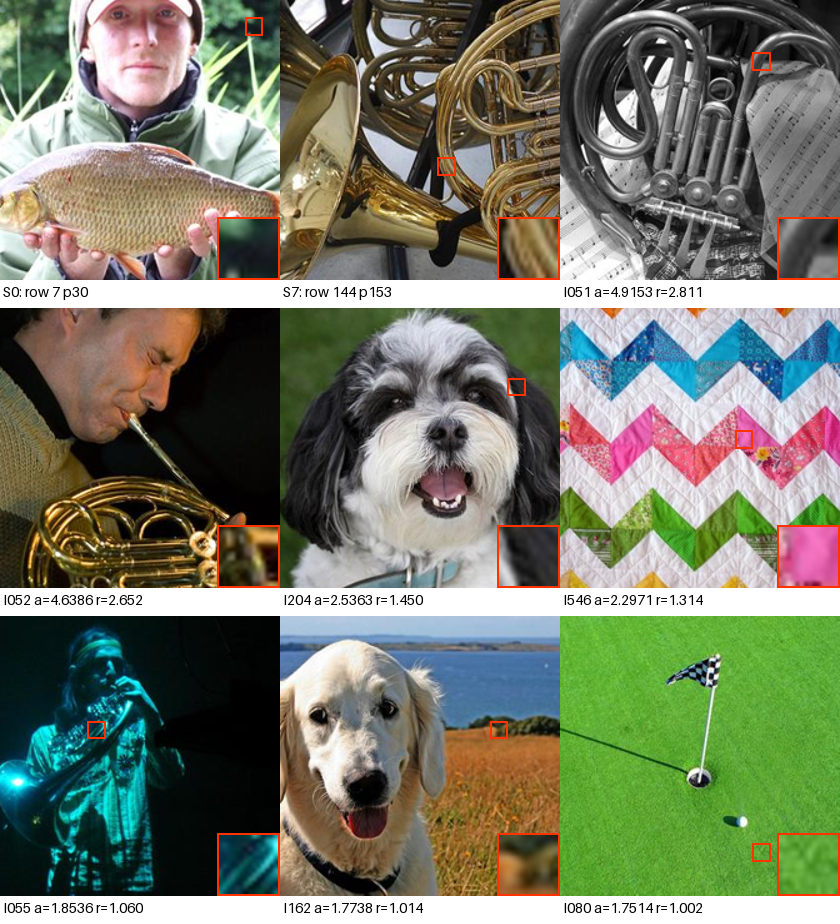

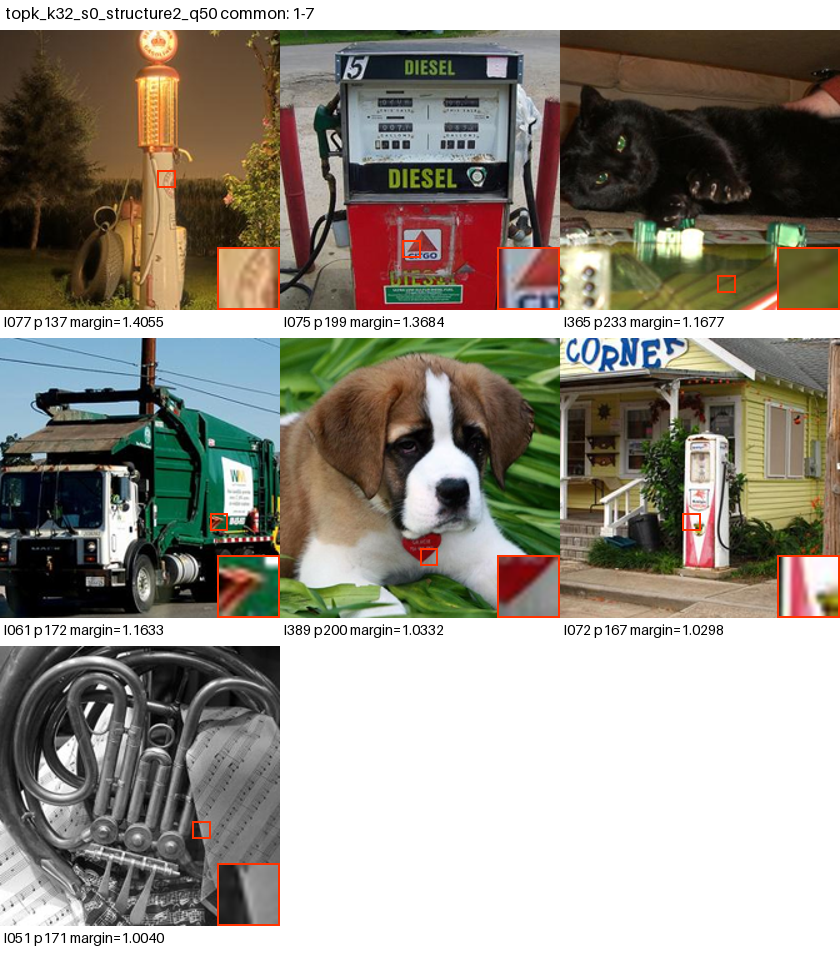

In [4]:
display(Image(filename=str(folder / "figures" /
    "semantic_witnesses_codexgen.png")))
display(Image(filename=str(folder / "figures" /
    "semantic_source_meet_codexgen.png")))
display(Image(filename=str(folder / "figures" /
    "semantic_counterexamples_codexgen.png")))

## Threshold sensitivity and full-dictionary closure

The native S0/S7 TopK meet retains feature 825 and
returns 66 images; its 24-coordinate projection is
zero and returns all 547. Raising the native threshold
by 1.5 retains seven instrument photographs, a post-hoc
observation. Full closure can add coordinates outside
a projection without establishing their visual meaning.

In [5]:
sensitivity = pd.read_json(
    folder / "sensitivity_codexgen.json")
display(sensitivity.drop(columns="common_ids"))
intents = json.loads(
    (folder / "full_intents_codexgen.json").read_text())
intents["topk_k32_s0:face6_q50"]["patch"]

,model,name,scale,patches,common,pooled
0,topk_k32_s0,source_0_7_native_meet,0.9,802,100,100
1,topk_k32_s0,source_0_7_native_meet,1.0,631,66,66
2,topk_k32_s0,source_0_7_native_meet,1.1,458,40,40
3,topk_k32_s0,source_0_7_native_meet,1.5,259,7,7
4,topk_k32_s0,face3_q80,0.9,19,15,265
5,topk_k32_s0,face3_q80,1.0,3,3,233
6,topk_k32_s0,face3_q80,1.1,0,0,164
7,topk_k32_s0,face6_q50,0.9,11,8,314
8,topk_k32_s0,face6_q50,1.0,6,5,306
9,topk_k32_s0,face6_q50,1.1,1,1,299


{'features': [329, 399, 468, 507, 515, 871, 1271, 1430],
 'values': [3.2984635829925537,
  2.269981622695923,
  3.0763649940490723,
  3.317631959915161,
  1.625866413116455,
  2.167074203491211,
  1.9102451801300049,
  5.272373199462891],
 'added': [399, 515]}

## Labels revealed after the first reading

These counts are a separate description of the same
records, not independent relevance annotations. A
tench label, for example, omits the pictured person.
The initial label-withheld interpretations are preserved
in `initial_reading_codexgen.json`.

In [6]:
path = folder / "labels_after_reading_codexgen.json"
labels = json.loads(path.read_text())
display(labels["topk_k32_s0"]["performance3_q80"])
display(labels["prisma_transcoder"]["repetition2_q80"])
display(labels["pretrained_ra"]["person_scene3_q50"])

{'pooled': {'French horn': 3},
 'pooled_datasets': {'imagenette': 3},
 'common': {},
 'common_datasets': {}}

{'pooled': {'tench': 2,
  'chain saw': 1,
  'church': 2,
  'French horn': 2,
  'garbage truck': 1,
  'gas pump': 6,
  'golf ball': 2,
  'parachute': 3,
  'Beagle': 2,
  'Australian terrier': 1,
  'Golden retriever': 1,
  'Samoyed': 2,
  'Dingo': 1,
  'wheaten_terrier': 2,
  'japanese_chin': 1,
  'scottish_terrier': 2,
  'miniature_pinscher': 1,
  'bengal': 1,
  'basset_hound': 2,
  'shiba_inu': 1,
  'abyssinian': 2,
  'bombay': 1,
  'english_cocker_spaniel': 1,
  'leonberger': 1,
  'russian_blue': 1,
  'samoyed': 1,
  'siamese': 1,
  'saint_bernard': 1,
  'n01440764': 1,
  'n01614925': 1,
  'n01664065': 1,
  'n01667778': 1,
  'n01687978': 1,
  'n01692333': 1,
  'n01728572': 1,
  'n01729977': 1,
  'n01739381': 1,
  'n01744401': 1,
  'n01753488': 1,
  'n01824575': 1,
  'n01855672': 1,
  'n02009229': 1,
  'n02025239': 1,
  'n02096177': 1,
  'n02098105': 1,
  'n02101006': 1,
  'n02112137': 1,
  'n02133161': 1,
  'n02481823': 1,
  'n02487347': 1,
  'n02490219': 1,
  'n02701002': 1,
  'n0283

{'pooled': {'tench': 4},
 'pooled_datasets': {'imagenette': 4},
 'common': {},
 'common_datasets': {}}